### Data Exploration 

#### Import essential libraries!

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder 
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../data/Breast_Cancer.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget distribution:")
print(df['Status'].value_counts())

Shape: (4024, 16)

First 5 rows:
   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiated     3  Regional          18        Positive   
4      Poorly differentiated     3  Regional          41        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive                      24                      1   
1          

In [4]:
df.isna()
##if it return False, it means there is no missing value in the dataset.

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4021,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4022,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df['Age'].describe()

count    4024.000000
mean       53.972167
std         8.963134
min        30.000000
25%        47.000000
50%        54.000000
75%        61.000000
max        69.000000
Name: Age, dtype: float64

In [6]:
df.isna().sum()
##it shows that there is no missing value in the dataset.

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [7]:
df.duplicated().sum()
##it shows that there is no duplicated value in the dataset.

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)
#it drop the duplicated value in the dataset if there is any. In this case, there is no duplicated value in the dataset, so it will not drop any value.

In [9]:
df['Status'].value_counts()

Status
Alive    3407
Dead      616
Name: count, dtype: int64

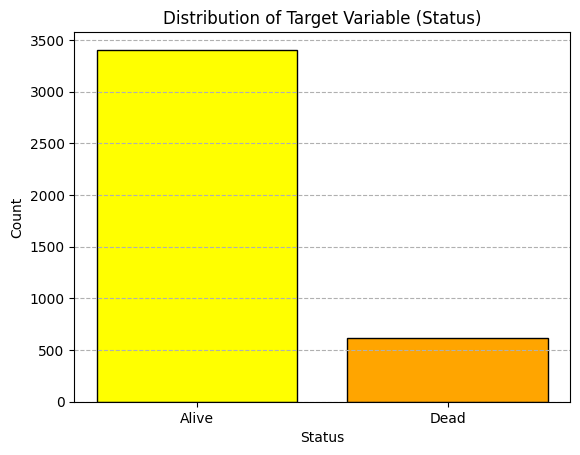

In [10]:
plt.bar(df['Status'].value_counts().index, df['Status'].value_counts().values, color=['yellow', 'orange'], edgecolor ='black')
plt.title('Distribution of Target Variable (Status)')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [11]:
print(df.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')


### Plot Histogram 
To see the the distribution of Age of having the Breast Cancer

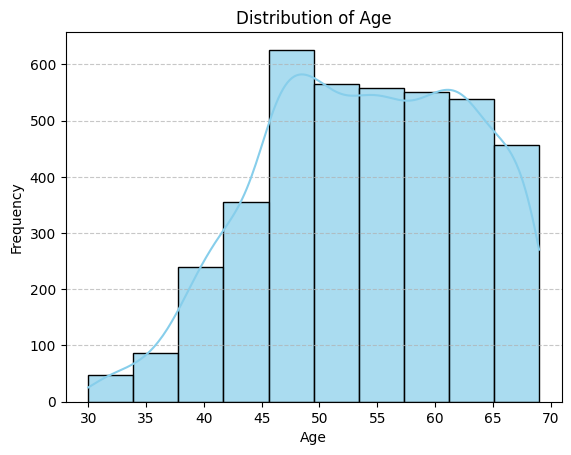

In [12]:
sns.histplot(df['Age'], edgecolor='black', bins=10, color='skyblue', alpha=0.7, kde=True)


plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Plot Pie chart
We plot Pie Chart to show how different contribute to the whole dataset

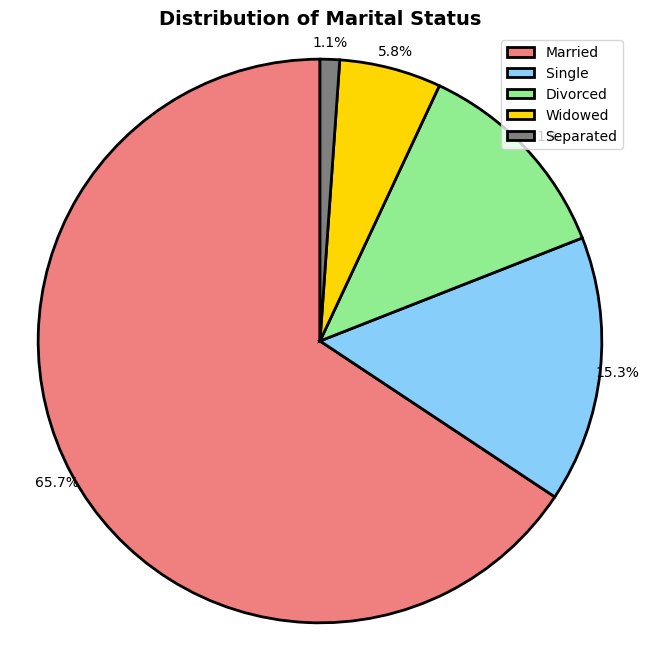

In [13]:
size = df['Marital Status'].value_counts()
label = df['Marital Status'].value_counts().index

plt.figure(figsize=(8, 8))
plt.pie(size, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['lightcoral', 'lightskyblue', 'lightgreen', 'gold', 'gray'], 
        explode=(0, 0, 0, 0, 0),
        pctdistance=1.06,
        shadow=False,
        wedgeprops={'edgecolor': 'black', 'linewidth':2}
        )
plt.title('Distribution of Marital Status', color='Black', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.legend(labels=label, loc='upper right')
plt.show()      

### Plot the Count plot 
We plot the count plot to specifically see distribution of Race to the Breast Cancer


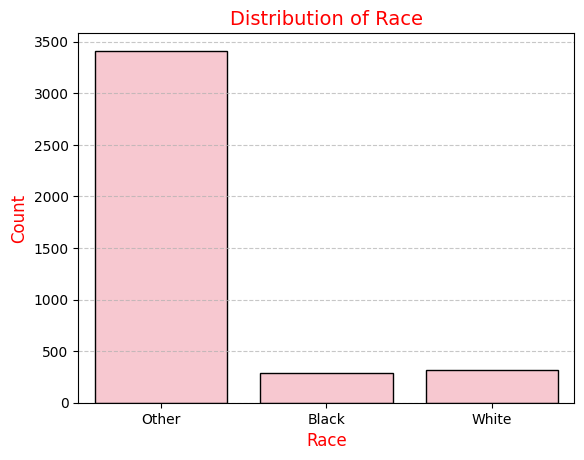

In [14]:
df['Race'].value_counts()
sns.countplot(x='Race', data=df, color ='pink', edgecolor='black')

plt.title('Distribution of Race', color='Red', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks([0, 1, 2], ['Other', 'Black','White'])
plt.xlabel('Race', color='Red', fontsize=12)
plt.ylabel('Count', color='Red', fontsize=12)
plt.show()

It plot shows that White race seem to have higher chances of having Breast Cancer.

### Plot Heat Map/Confusion Matrix 
We plot the heat map to see the correlation between numerical features like Tumor size, Survival month,....

In [15]:
df_numeric =df.select_dtypes(include=['number'])
df_numeric.corr()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
Age,1.000000,-0.077069,-0.033186,0.012743,-0.009224
Tumor Size,-0.077069,1.000000,0.104258,0.242247,-0.087016
Regional Node Examined,-0.033186,0.104258,1.000000,0.411520,-0.022166
Reginol Node Positive,0.012743,0.242247,0.411520,1.000000,-0.135330
Survival Months,-0.009224,-0.087016,-0.022166,-0.135330,1.000000


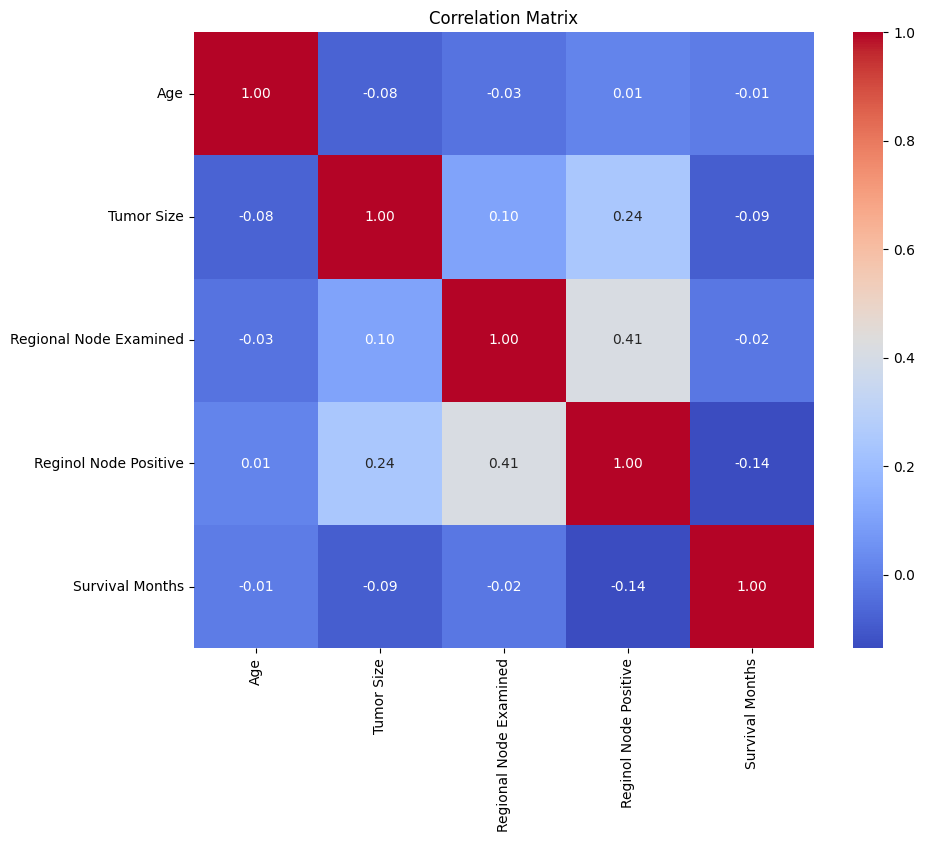

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#### VIF = Variance Inflation Factor 
We use VIF to detect the Multicolinearity
- VIF > 10 ---> Serious Multicolinearity, we need to drop out one feature and combine features together if needed (Regional Node Examined/Reginol Node Positive )
- VIF 5-10 ---> Moderate, it is okay to move on to the next step!
- VIF < 5  ---> Totally Fine, good to go!!

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 4023 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4023 non-null   int64
 1   Race                    4023 non-null   str  
 2   Marital Status          4023 non-null   str  
 3   T Stage                 4023 non-null   str  
 4   N Stage                 4023 non-null   str  
 5   6th Stage               4023 non-null   str  
 6   differentiate           4023 non-null   str  
 7   Grade                   4023 non-null   str  
 8   A Stage                 4023 non-null   str  
 9   Tumor Size              4023 non-null   int64
 10  Estrogen Status         4023 non-null   str  
 11  Progesterone Status     4023 non-null   str  
 12  Regional Node Examined  4023 non-null   int64
 13  Reginol Node Positive   4023 non-null   int64
 14  Survival Months         4023 non-null   int64
 15  Status                  4023 non-null

In [18]:
print(df.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

multi_corr = df[['Age', 
        'Tumor Size',
        'Regional Node Examined',
        'Reginol Node Positive', 
        'Survival Months']]

vif_data = pd.DataFrame()
vif_data['feature'] = multi_corr.columns

vif_data['VIF'] = [variance_inflation_factor(multi_corr.values, i)
                          for i in range(len(multi_corr.columns))]
print(vif_data)

                  feature        VIF
0                     Age  11.168732
1              Tumor Size   3.076295
2  Regional Node Examined   4.741190
3   Reginol Node Positive   2.139869
4         Survival Months   8.732807


<Axes: >

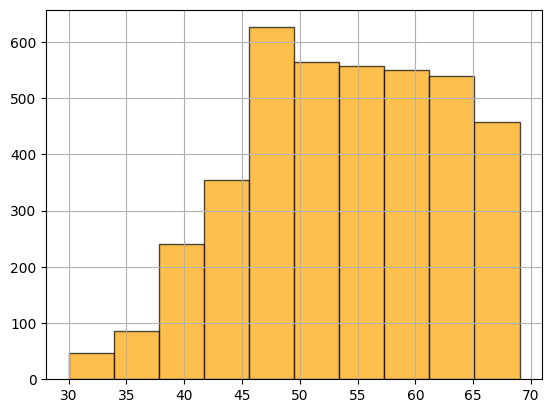

In [20]:
df['Age'].hist(bins=10, edgecolor='black', color='orange', alpha=0.7)

In [21]:
df[['Age', 'Tumor Size', 'Survival Months']].corr() 

,Age,Tumor Size,Survival Months
Age,1.000000,-0.077069,-0.009224
Tumor Size,-0.077069,1.000000,-0.087016
Survival Months,-0.009224,-0.087016,1.000000


The Age feature is likely to have a lot of outlier, idicating that the Age has high correlation with other variables in the model, not necessarily outliers in Age itself. Boxplots detect univariate outliers (extreme values in a single variable based on IQR), but VIF assesses how much Age is linearly dependent on the other predictors (e.g., it might correlate strongly with Survival Months or Tumor Size). This can inflate VIF even if Age's distribution looks normal without many outliers.

In this case, apply log on the Age which appears to be normally distributed, it could worsen the issues or introduce negative values/invalid data.
We can drop the Age, but Age in medical discovery is very important. 

Logging can reduce multicollinearity indirectly by:

- Compressing the scale of skewed variables — Many correlated features are correlated because they share an underlying exponential or multiplicative relationship (e.g., income and house size both grow multiplicatively). Log-transforming them converts multiplicative relationships into additive ones, which can reduce the correlation between them.
- Stabilizing variance — Features with high variance (often right-skewed) tend to dominate the model and create spurious correlations with other features. Logging compresses the upper tail, making the distributions more symmetric and comparably scaled.
- Linearizing relationships — If two features have a power-law relationship with each other (e.g., X₂ ≈ X₁²), they'll be highly correlated. After logging, log(X₂) ≈ 2·log(X₁), which is a linear relationship — and linear relationships between features are more "honest" for linear models to handle. Some regularization techniques also work better in this regime.

To reduce multicolinerity, we can use:
- Remove or combine correlated features (e.g., drop Age if redundant). In this case, we cannot drop the Age as the Age in medical discovery is very important. 
- Use dimensionality reduction like PCA.
- Apply regularization (e.g., Ridge regression) in modeling.

#### Distribution of each feature

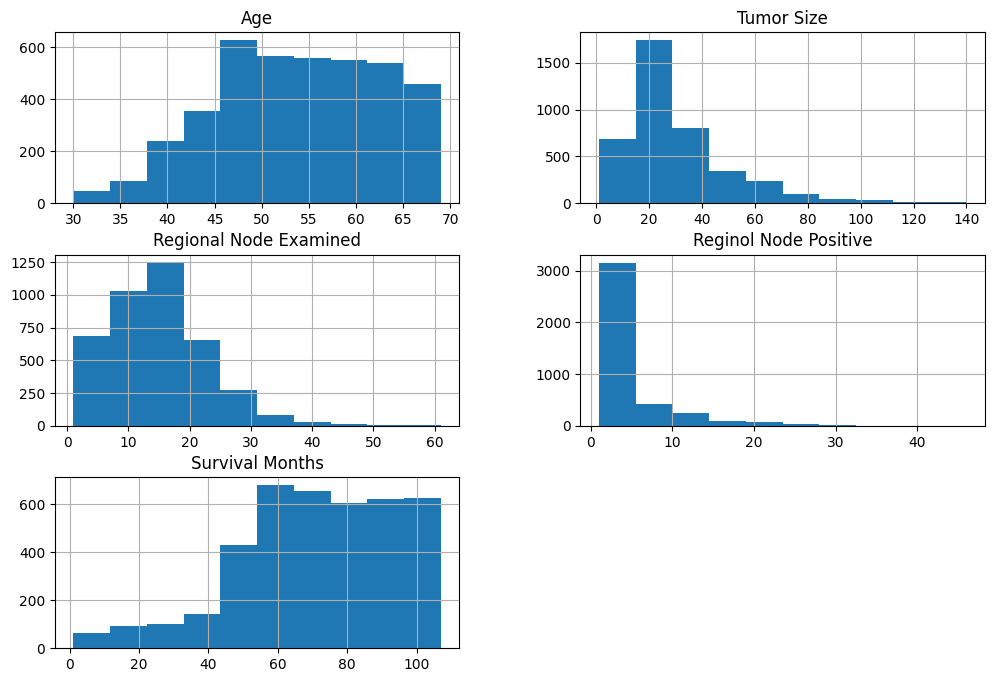

In [22]:
# Distribution of each feature
df_numeric.hist(figsize=(12, 8), bins=10)
plt.grid(True)
plt.show()


- The Age is not well distributed
- The Survival Month Feature is fairly uniform which mean good spread across time

But 
- The Tumor Size is Rigth skewed 
- The Regional Node Examined is Right Skewed 
- The Reginol Node Positive is Highly Right Skewed 


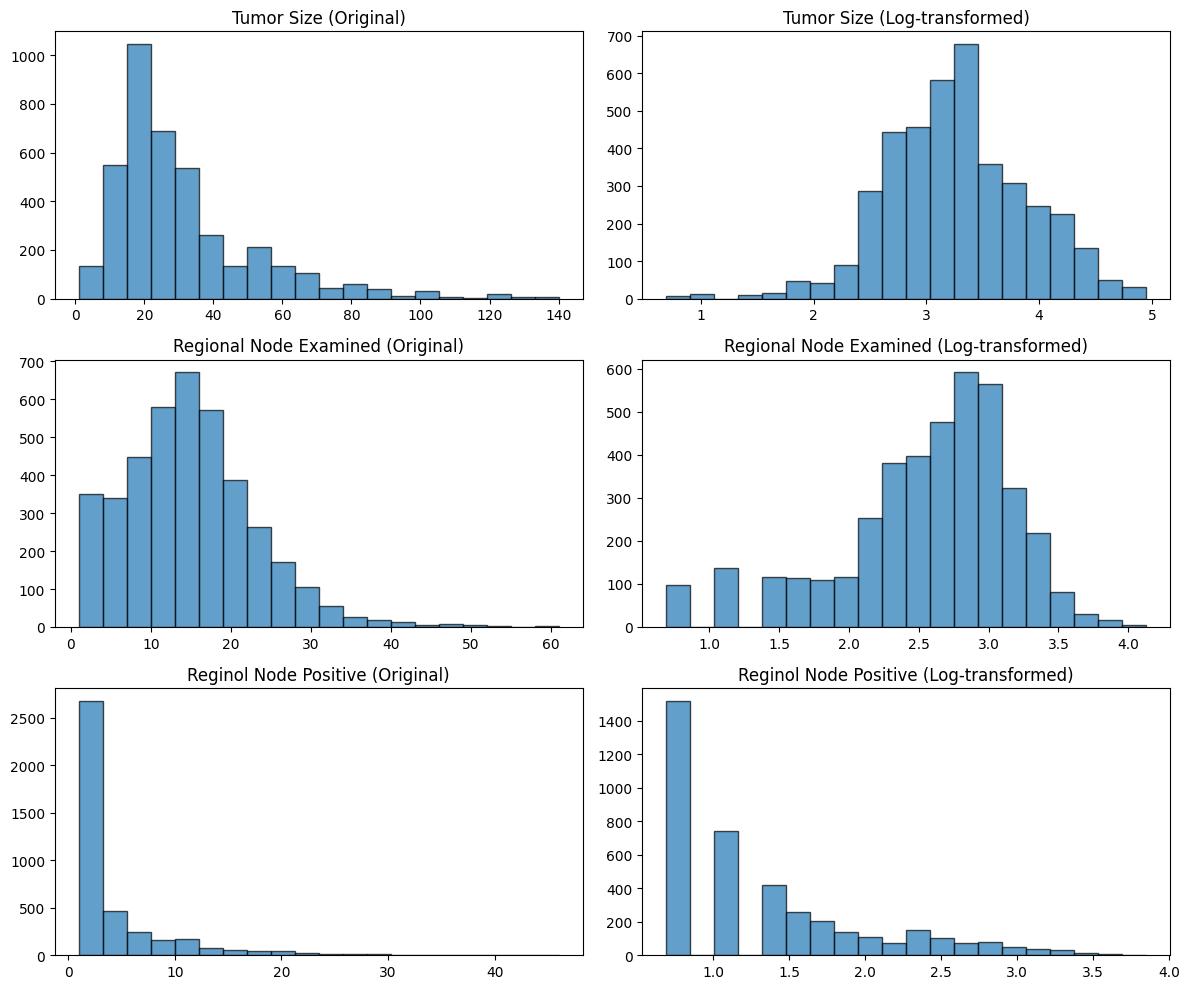

In [23]:
# Transform skewed features
df['Tumor Size_log'] = np.log1p(df['Tumor Size'])
df['Regional Node Examined_log'] = np.log1p(df['Regional Node Examined'])
df['Reginol Node Positive_log'] = np.log1p(df['Reginol Node Positive'])

# Visualize before/after
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, col in enumerate(['Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']):
    axes[i, 0].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{col} (Original)')
    axes[i, 1].hist(df[f'{col}_log'], bins=20, edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'{col} (Log-transformed)')
plt.tight_layout()
plt.show()

In [24]:
# from scipy.stats import boxcox

# df['Tumor Size_boxcox'], lambda_tumor = boxcox(df['Tumor Size'] + 1)
# df['Regional Node Examined_boxcox'], lambda_node_ex = boxcox(df['Regional Node Examined'] + 1)
# df['Reginol Node Positive_boxcox'], lambda_node_pos = boxcox(df['Reginol Node Positive'] + 1)

# # Visualize before/after
# fig, axes = plt.subplots(3, 2, figsize=(12, 10))
# for i, col in enumerate(['Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']):
#     axes[i, 0].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
#     axes[i, 0].set_title(f'{col} (Original)')
#     axes[i, 1].hist(df[f'{col}_log'], bins=20, edgecolor='black', alpha=0.7)
#     axes[i, 1].set_title(f'{col} (Log-transformed)')
# plt.tight_layout()
# plt.show()

#### Check for outliers

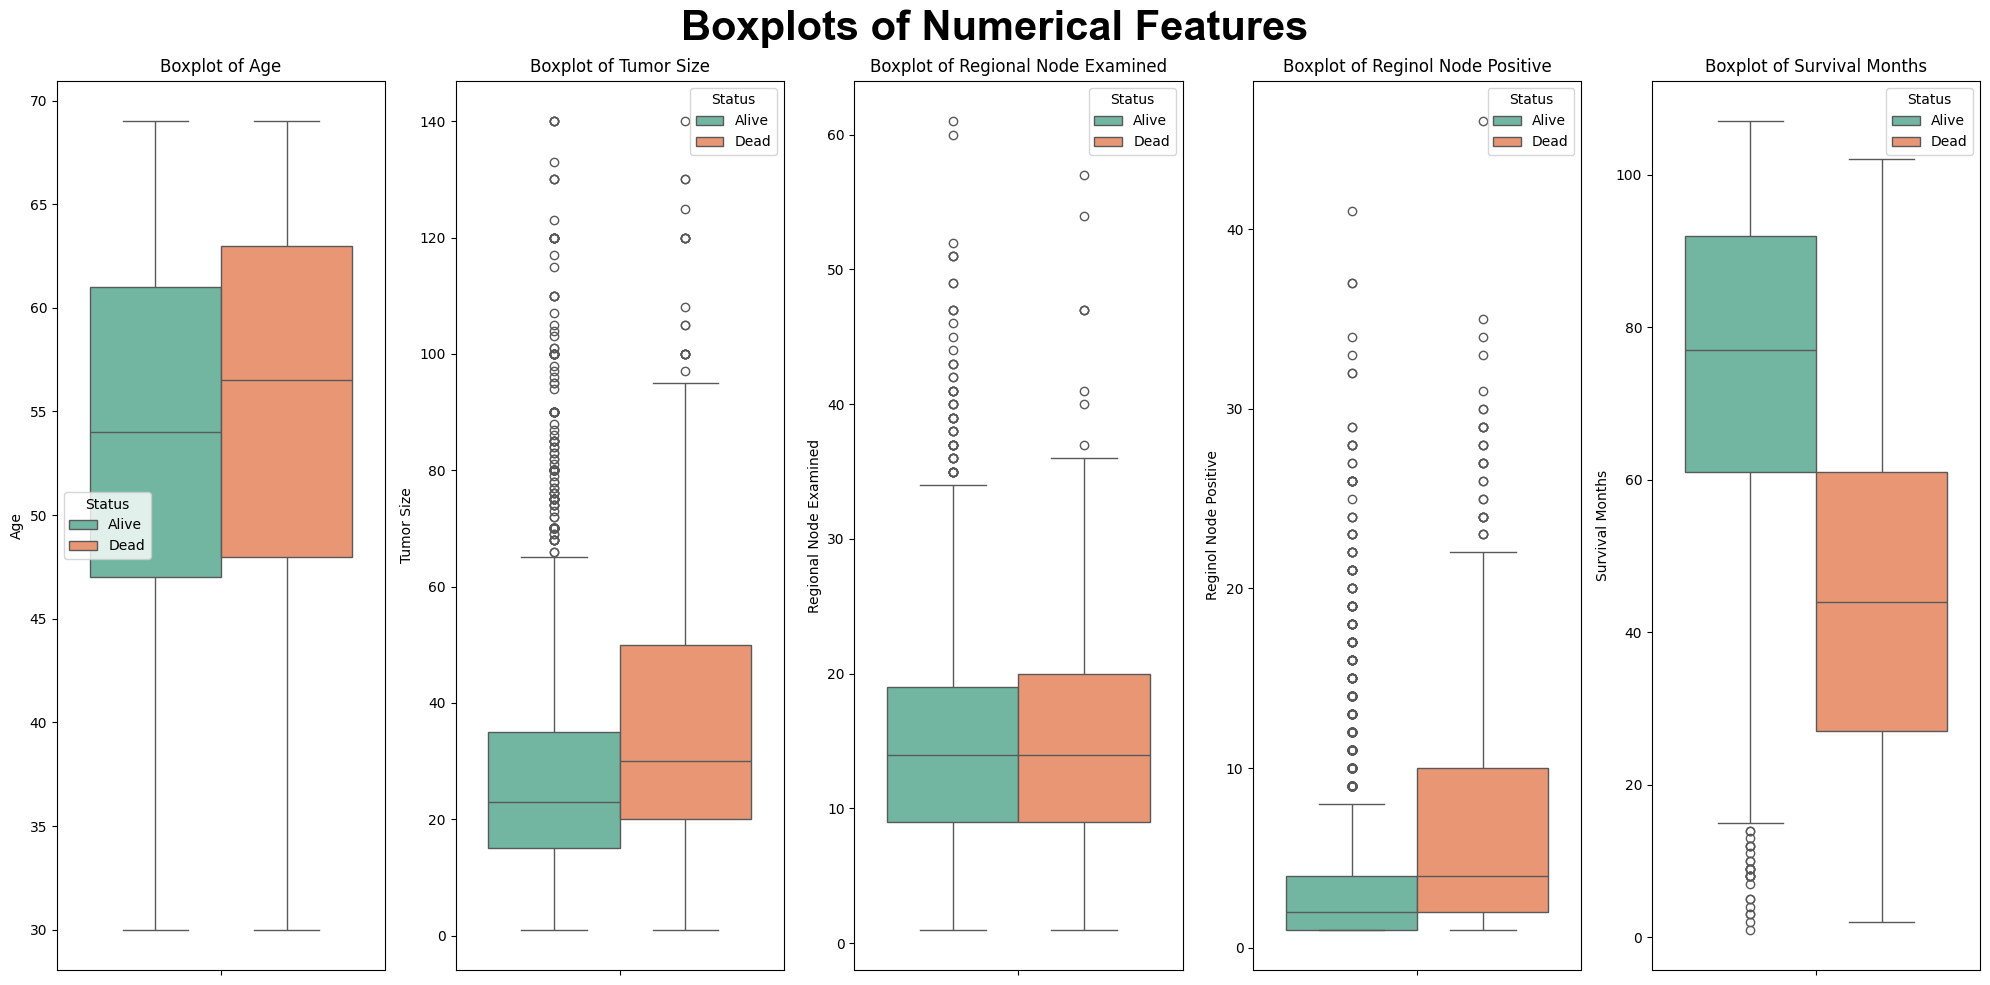

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20,10))
axes = axes.flatten()
for axes, col in zip(axes, df_numeric):
    sns.boxplot(df, y=col, ax=axes, hue= 'Status', palette='Set2')
    axes.set_title(f'Boxplot of {col}')
plt.suptitle('Boxplots of Numerical Features', fontsize=30, fontweight='bold', color ='BLACK', font = 'Arial')
plt.tight_layout()
plt.show()
   


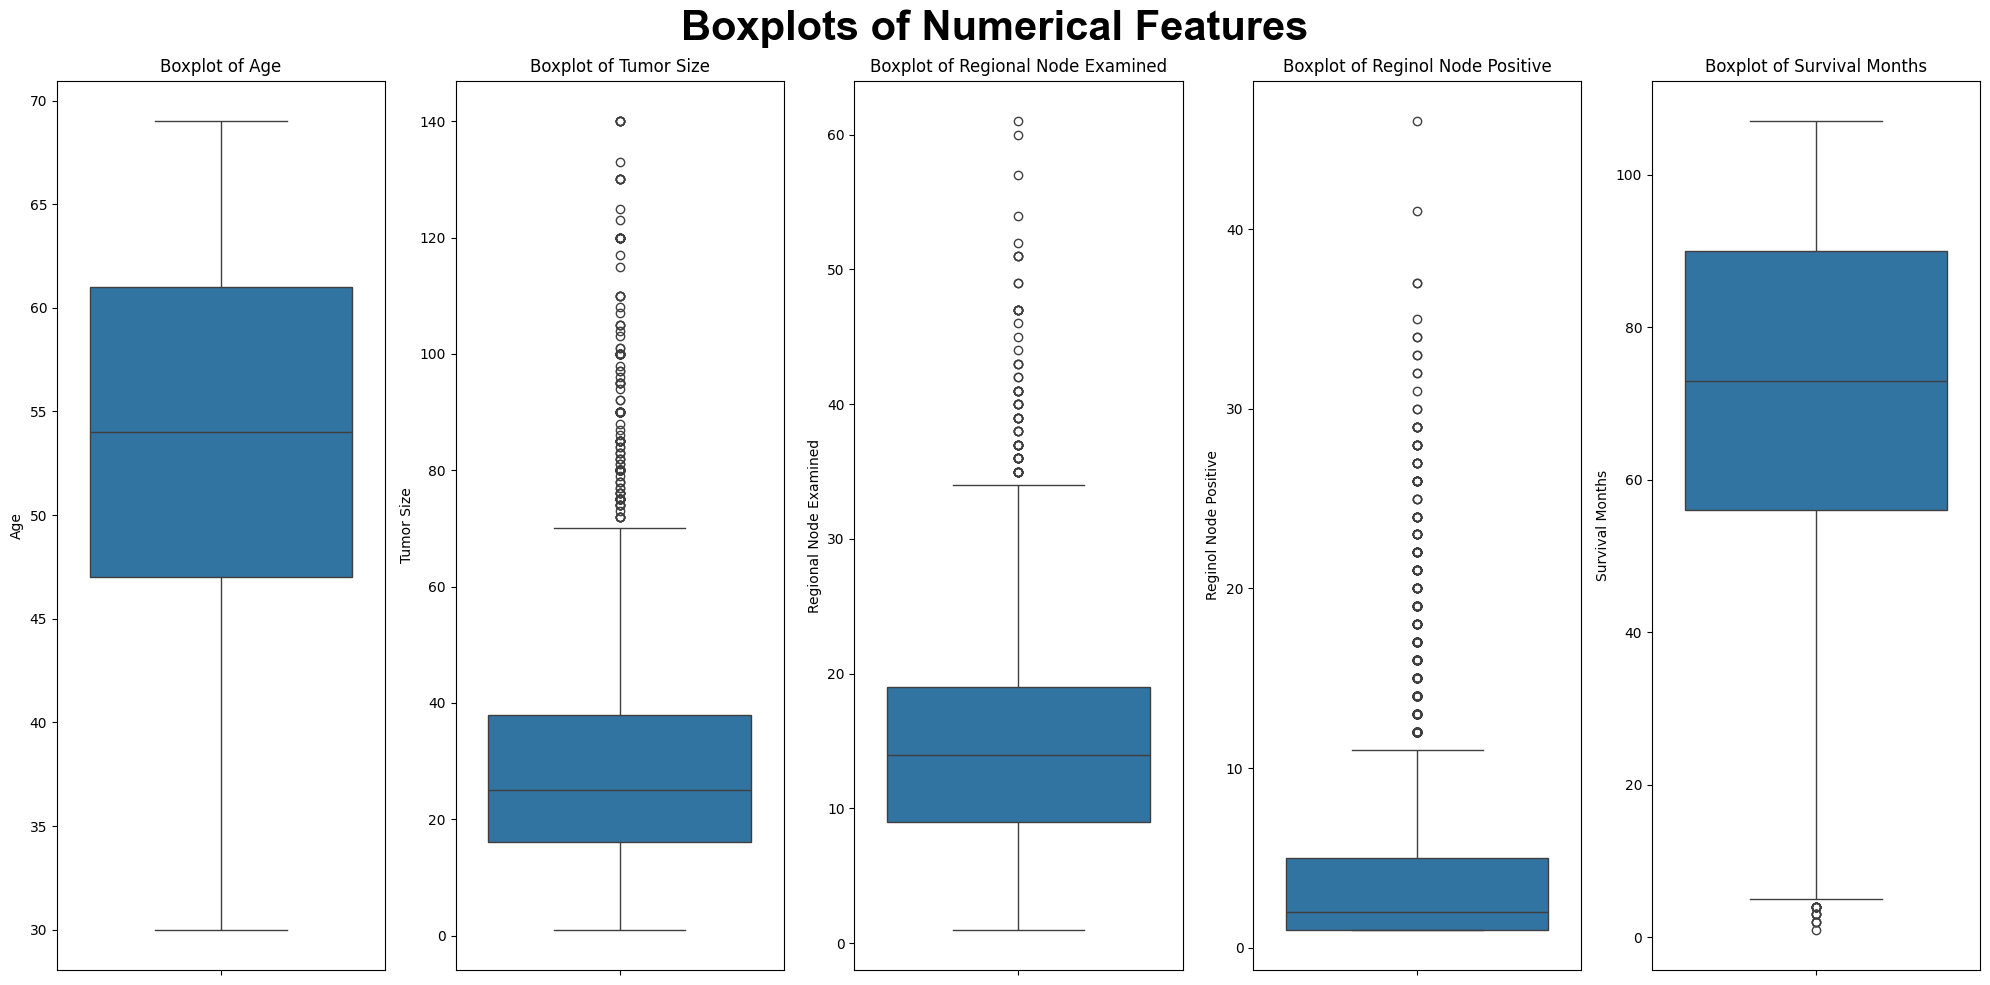

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(20,10))
axes = axes.flatten()
for axes, col in zip(axes, df_numeric):
    sns.boxplot(df, y=col, ax=axes)
    axes.set_title(f'Boxplot of {col}')
plt.suptitle('Boxplots of Numerical Features', fontsize=30, fontweight='bold', color ='BLACK', font = 'Arial')
plt.tight_layout()
plt.show()

In [27]:
df_numeric.head()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
0,68,4,24,1,60
1,50,35,14,5,62
2,58,63,14,7,75
3,58,18,2,1,84
4,47,41,3,1,50


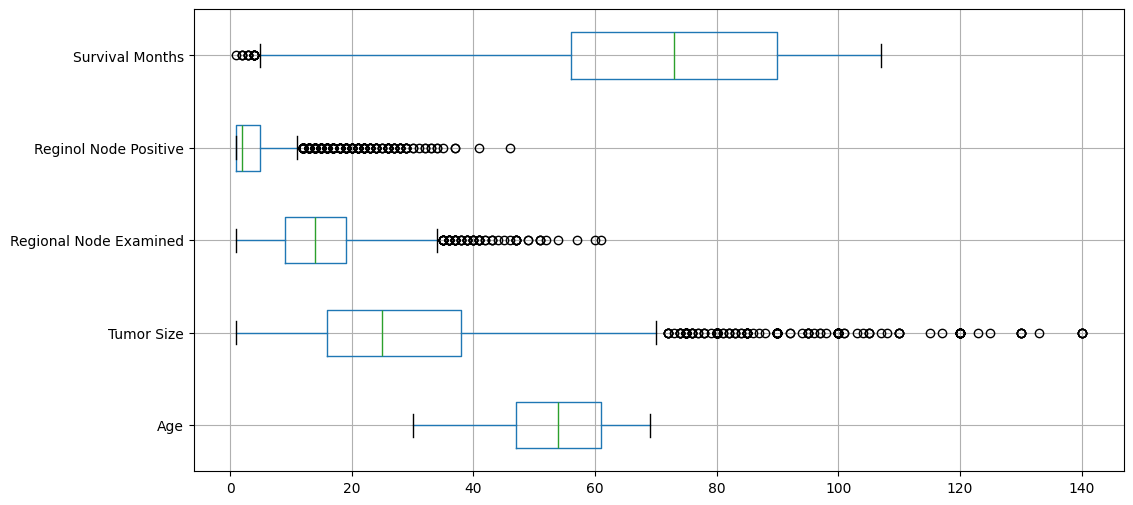

In [28]:

df_numeric.boxplot(figsize=(12, 6), vert=False)

plt.show()

It appears to us that the 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive' Feature has a lot of outliers. 


### IQR-Based Capping 
Instead of removing the outlier (which loses data), capping clips them to a reasonable boundary. 
The IQR method gives us a principled, data-driven way to define those boundaries. 

In [29]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower_bound, upper_bound)
    return data

for col in ['Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']:
    cap_outliers(df_numeric, col)

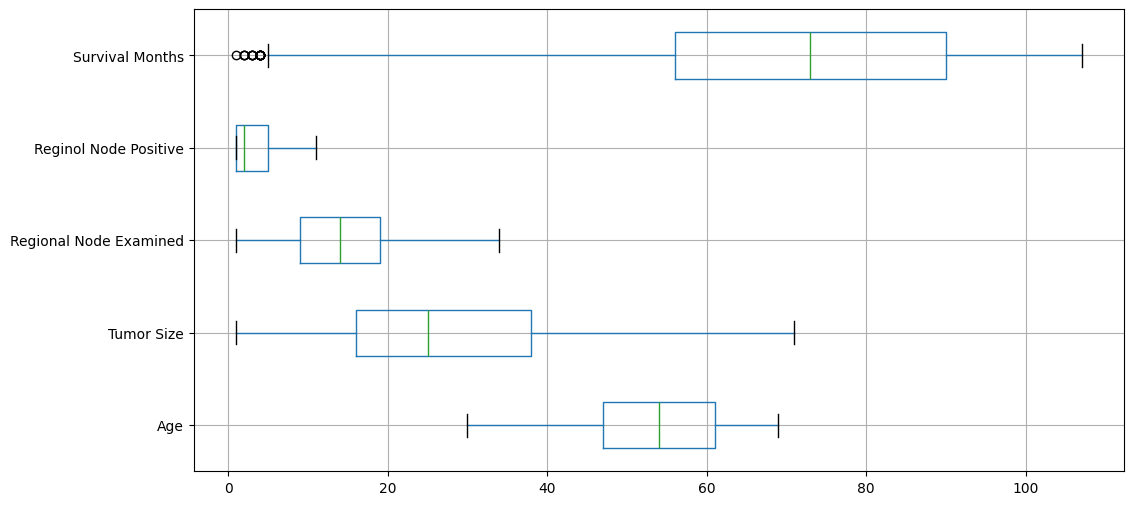

In [30]:

df_numeric.boxplot(figsize=(12, 6), vert=False)

plt.show()

### Label Encoder 
We convert the categorical features (string) to numerical values using the Label Encoder. 
    This would ensure that all features are numerical before scaling

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoder = {}

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Status')

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoder[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.fit_transform(le.classes_)))}")

Encoded 'Race': {'Black': np.int64(0), 'Other': np.int64(1), 'White': np.int64(2)}
Encoded 'Marital Status': {'Divorced': np.int64(0), 'Married': np.int64(1), 'Separated': np.int64(2), 'Single ': np.int64(3), 'Widowed': np.int64(4)}
Encoded 'T Stage ': {'T1': np.int64(0), 'T2': np.int64(1), 'T3': np.int64(2), 'T4': np.int64(3)}
Encoded 'N Stage': {'N1': np.int64(0), 'N2': np.int64(1), 'N3': np.int64(2)}
Encoded '6th Stage': {'IIA': np.int64(0), 'IIB': np.int64(1), 'IIIA': np.int64(2), 'IIIB': np.int64(3), 'IIIC': np.int64(4)}
Encoded 'differentiate': {'Moderately differentiated': np.int64(0), 'Poorly differentiated': np.int64(1), 'Undifferentiated': np.int64(2), 'Well differentiated': np.int64(3)}
Encoded 'Grade': {' anaplastic; Grade IV': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3)}
Encoded 'A Stage': {'Distant': np.int64(0), 'Regional': np.int64(1)}
Encoded 'Estrogen Status': {'Negative': np.int64(0), 'Positive': np.int64(1)}
Encoded 'Progesterone Status': {'Neg

In [32]:
le_target = LabelEncoder()
df['Status'] = le_target.fit_transform(df['Status'])
print(f"\nTarget encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")


Target encoding: {'Alive': np.int64(0), 'Dead': np.int64(1)}


### Standard Scaler 
We use Standard Scaler to ensure that all of the features contribute equally in the process building the model


In [33]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Status')
y = df['Status']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(X_scaled.head())


        Age      Race  Marital Status  T Stage    N Stage  6th Stage  \
0  1.565507  0.397217       -0.349151 -1.025548 -0.632319  -1.043977   
1 -0.442973  0.397217       -0.349151  0.280905  0.809756   0.535237   
2  0.449685  0.397217       -1.289335  1.587359  2.251832   2.114452   
3  0.449685  0.397217       -0.349151 -1.025548 -0.632319  -1.043977   
4 -0.777719  0.397217       -0.349151  0.280905 -0.632319  -0.254370   

   differentiate     Grade   A Stage  Tumor Size  Estrogen Status  \
0       0.304489  1.351595  0.152983   -1.253728         0.267688   
1      -0.679414 -0.205080  0.152983    0.214171         0.267688   
2      -0.679414 -0.205080  0.152983    1.540015         0.267688   
3       0.304489  1.351595  0.152983   -0.590806         0.267688   
4       0.304489  1.351595  0.152983    0.498280         0.267688   

   Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0             0.458176                1.190429              -0.618278   
1     

### Train Test Split 
80/20

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)       

In [35]:
from sklearn.linear_model import LogisticRegression 
from mlxtend.classifier import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import xgboost

model_LogisticRegression = LogisticRegression()
model_LogisticRegression.fit(X_train, y_train)
y_pred = model_LogisticRegression.predict(X_test)    
acc_lgr = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {acc_lgr:.4f}")

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)  
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Accuracy: {acc_knn:.4f}")

# model_GNB = GaussianNB()
# model_GNB.fit(X_train, y_train)
# y_pred_gnb = model_GNB.predict(X_test)
# acc_gnb = accuracy_score(y_test, y_pred_gnb)
# print(f"Gaussian Naive Bayes Accuracy: {acc_gnb:.4f}")
  
xgb_clf = xgboost.XGBClassifier(use_label_encoder=False, eval_metric="logloss", verbosity=0)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.4f}")   

base_learners = [
    KNeighborsClassifier(),
]
meta_model = LogisticRegression()

stacking_model = StackingClassifier(classifiers=base_learners, meta_classifier=meta_model, use_probas=True)

model_stack = stacking_model.fit(X_train, y_train)   
pred_stack = model_stack.predict(X_test)

acc_stack = accuracy_score(y_test, pred_stack)
print('Accuracy Score of Stacked Model:', f'{acc_stack:.4f}')

Logistic Regression Accuracy: 0.8969
K-Nearest Neighbors Accuracy: 0.8733
XGBoost Accuracy: 0.9019
Accuracy Score of Stacked Model: 0.8733


### Hyperparameter tuning (RandomizedSearchCV)
We use RandomizedSearchCV with StratifiedKFold to tune a RandomForest model and improve generalization.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Random Forest baseline + tuning
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 200, 400, 800],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)
rf_search.fit(X_train, y_train)

print('Best RF params:', rf_search.best_params_)
print('Best RF CV accuracy:', rf_search.best_score_)

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print('RF Test accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nRF Classification report:')
print(classification_report(y_test, y_pred_rf))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
